In [1]:
using QuantEcon, CSV, DataFrames, LinearAlgebra, Parameters, Plots;pyplot()
using Printf

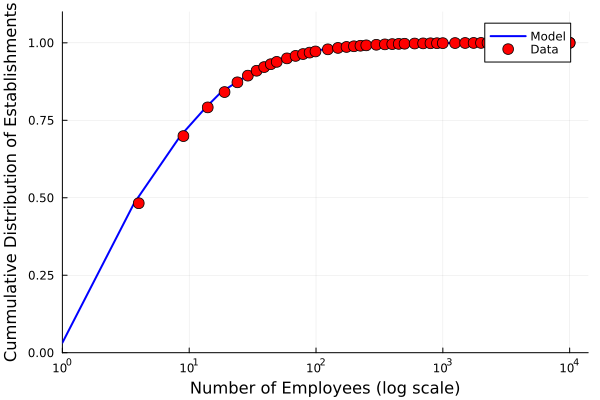

In [2]:
data_raw = CSV.read("R&R 2008/files/establishment_dist.txt",
            DataFrame;
            header = false,
            delim = '\t',
            types = [Int, Float64])
grid_emp = data_raw[:,1]
dist_emp = data_raw[:,2]
cdf_emp = cumsum(dist_emp)
α = 0.283
γ = 0.567
N_s = 100
N_data = length(dist_emp[:,1])
z_ns = grid_emp[N_data]^(1-α-γ)
s = 10 .^ range(0, log10(z_ns), length=N_s)
z = s.^(1/(1-α-γ))
hs = zeros(N_s)
grid_emp2 = [0;grid_emp]

for i in 2:length(grid_emp2)
    I = findall((z .<= grid_emp2[i]) .& (z .> grid_emp2[i-1]))
    if !isempty(I)
        hs[I] .= dist_emp[i-1] / length(I)
    end
end

gr()
plot(z, cumsum(hs), xscale =:log10 , label = "Model", linewidth = 2,color =:blue )
scatter!(grid_emp, cdf_emp, label="Data",
         markershape=:circle, color=:red,      # ← 用 color 替代 markercolor
         markerstrokecolor=:black,             # 明确边框色，避免 PyPlot 推断
         markerstrokewidth=1, markersize=6)
xlabel!("Number of Employees (log scale)")
ylabel!("Cummulative Distribution of Establishments")
xlims!(1,14000)
ylims!(0,1.1)

In [3]:
function setup(;
    α = 0.85/3,
    γ = 0.85/3 *2,
    β = 0.96,
    δ = 0.08,
    c_e = 1.0,
    c_f = 0.0,
    λ = 0.1,
    grid_z = s,
    pdf_z = hs[:],
    N_z = N_s,
    dist_τ = repeat([0.0  1.0 0.0],N_z,1),
    grid_τ = [0.0; 0.0;0.0])

    r = 1/β -1 +δ
    R = r-δ
    ρ = (1-λ)/(1+R)
    F = pdf_z .* dist_τ

    
    return (α = α, β = β, δ = δ, c_e = c_e, c_f = c_f,
            λ = λ, grid_z = grid_z, pdf_z = pdf_z,
            N_z = N_z, r = r, ρ = ρ, grid_τ = grid_τ, F =F,γ =γ)
end

function solve_wage(par)
    sol_last = Ref{Any}(nothing)
    function obj_wage(w_guess)
        @unpack α, β, ρ, γ, r,grid_z,grid_τ,F,N_z,c_f,c_e =par
        N_τ = length(grid_τ)
        function solve_incumbent(w_guess)
            π = fill(0.0,N_z,N_τ)
            k = fill(0.0,N_z,N_τ)
            n = fill(0.0, N_z, N_τ)
            V = fill(0.0,N_z,N_τ)
                function demand_factor(z,τ)
                    kk = ((1.0 -τ)*z)^(1/(1-α-γ)) * (γ/w_guess)^(γ/(1-α-γ))*(α/r)^((1-γ)/(1-α-γ))
                    nn = ((1-τ)*z*γ*kk^α /w_guess)^(1/(1-γ))
                    return kk,nn
                end    
            for iZ in 1:N_z, iτ in 1:N_τ
                k[iZ,iτ],n[iZ,iτ] = demand_factor(grid_z[iZ],grid_τ[iτ])
                π[iZ,iτ] = (1-grid_τ[iτ])*grid_z[iZ]* k[iZ,iτ]^α *n[iZ,iτ]^γ-
                            w_guess*n[iZ,iτ]-r*k[iZ,iτ]-c_f
            end
            V = π./(1-ρ)
            χ = 1*(V .>= 0.0)
            return (V = V, π = π, n =n, k=k, χ = χ)
        end

        sol = solve_incumbent(w_guess)
        sol_last[] = sol
        
        return sum((sol.χ .* sol.V  ).*F)-c_e
    end
    w = QuantEcon.brent(obj_wage,0.001,25.0)
    return (V = sol_last[].V, π = sol_last[].π, n = sol_last[].n,
            k = sol_last[].k, χ = sol_last[].χ, w= w)
end

solve_wage (generic function with 1 method)

In [5]:
params = setup()

(α = 0.2833333333333333, β = 0.96, δ = 0.08, c_e = 1.0, c_f = 0.0, λ = 0.1, grid_z = [1.0, 1.0140528875638688, 1.0283032587766203, 1.042753888853768, 1.057407592010617, 1.0722672220103233, 1.0873356727196564, 1.1026158786725693, 1.1181108156416912, 1.1338235012178495  …  3.5111917342151355, 3.5605341168712457, 3.6105699024829563, 3.661308835364038, 3.7127607967640084, 3.7649358067924723, 3.8178440263705107, 3.8714957592094836, 3.925901453817649, 3.9810717055349776], pdf_z = [0.03215732993333333, 0.03215732993333333, 0.03215732993333333, 0.03215732993333333, 0.03215732993333333, 0.03215732993333333, 0.03215732993333333, 0.03215732993333333, 0.03215732993333333, 0.03215732993333333  …  1.96759e-5, 1.60263e-5, 7.231114285714286e-6, 7.231114285714286e-6, 7.231114285714286e-6, 7.231114285714286e-6, 7.231114285714286e-6, 7.231114285714286e-6, 7.231114285714286e-6, 0.0], N_z = 100, r = 0.12166666666666674, ρ = 0.864, grid_τ = [0.0, 0.0, 0.0], F = [0.0 0.03215732993333333 0.0; 0.0 0.0321573299

In [7]:
sol = solve_wage(params)

(V = [0.05687523531410512 0.05687523531410512 0.05687523531410512; 0.06242050054435741 0.06242050054435741 0.06242050054435741; … ; 518.225961635174 518.225961635174 518.225961635174; 568.7523531410551 568.7523531410551 568.7523531410551], π = [0.007735032002718297 0.007735032002718297 0.007735032002718297; 0.008489188074032608 0.008489188074032608 0.008489188074032608; … ; 70.47873078238368 70.47873078238368 70.47873078238368; 77.3503200271835 77.3503200271835 77.3503200271835], n = [0.015415755600131425 0.015415755600131425 0.015415755600131425; 0.016918772740286903 0.016918772740286903 0.016918772740286903; … ; 140.46262360218623 140.46262360218623 140.46262360218623; 154.15755600131527 154.15755600131527 154.15755600131527], k = [0.12008725483672228 0.12008725483672228 0.12008725483672228; 0.13179561393475275 0.13179561393475275 0.13179561393475275; … ; 1094.1903409137174 1094.1903409137174 1094.1903409137174; 1200.872548367232 1200.872548367232 1200.872548367232], χ = [1 1 1; 1 1 

In [11]:
function model_stats(par,sol;model_id = 2)
    @unpack F, λ, grid_z,α,γ,c_f = par
    μ_hat = sol.χ .* F ./λ
    E = 1.0 ./ sum(μ_hat .*sol.n)
    μ = E .* μ_hat
    K = sum(μ .* sol.k)
    N = 1.0
    y = grid_z .* sol.k .^α .* sol.n .^γ 
    Y = sum( y .* μ)
    KY = K/Y
    A = Y/K^α
    norm_emp = sol.n[1,model_id]
    n_norm = sol.n ./ norm_emp
    mass = sum(μ)
    emp_per_firm = 1.0 /(mass * norm_emp)
    share_K = (sol.k .* μ) ./ K 
    share_N = (sol.n .* μ) ./ N 
    share_Y = (y .* μ) ./Y
    model_n = n_norm[:,model_id]
    model_sN = share_N[:,model_id]
    model_μ = μ[:,model_id]./sum(μ[:,model_id])
    cdf_plants = zeros(3)
    cdf_sN = zeros(3)

    id_5 = findall(model_n .< 5.0)
    id_50 = findall(5.0 .<= model_n .< 50.0)
    id_rest = findall(50.0 .<= model_n)
    cdf_plants[1] = sum(model_μ[id_5])
    cdf_plants[2] = sum(model_μ[id_50])
    cdf_plants[3] = sum(model_μ[id_rest])
    cdf_sN[1] = sum(model_sN[id_5])
    cdf_sN[2] = sum(model_sN[id_50])
    cdf_sN[3] = sum(model_sN[id_rest])

    return (K = K, N = N, μ = μ, KY = KY, A = A, mass = mass, Y = Y,
            n_norm = n_norm, share_N = share_N,
            model_n = model_n, model_sN = model_sN,
            model_μ = model_μ, cdf_plants = cdf_plants,
            cdf_sN = cdf_sN, share_K = share_K, share_Y = share_Y,
            id_5 = id_5, id_50 = id_50, id_rest =id_rest, norm_emp =norm_emp)
end



    agg = model_stats(params, sol)


(K = 7.789903910755989, N = 1.0, μ = [0.0 0.11864197607105348 0.0; 0.0 0.11864197607105348 0.0; … ; 0.0 2.6678635627750908e-5 0.0; 0.0 0.0 0.0], KY = 2.32876712328767, A = 1.8698435798836992, mass = 3.6893686306525906, Y = 3.3450763852069856, n_norm = [1.0 1.0 1.0; 1.097498765493056 1.097498765493056 1.097498765493056; … ; 9111.627561154948 9111.627561154948 9111.627561154948; 10000.000000000065 10000.000000000065 10000.000000000065], share_N = [0.0 0.0018289557070280012 0.0; 0.0 0.0020072766306047105 0.0; … ; 0.0 0.003747351154400651 0.0; 0.0 0.0 0.0], model_n = [1.0, 1.097498765493056, 1.2045035402587827, 1.3219411484660288, 1.4508287784959406, 1.5922827933410924, 1.7475284000076852, 1.9179102616724895, 2.104904144512022, 2.31012970008316  …  4328.761281083086, 4750.810162102824, 5214.008287999718, 5722.367659350251, 6280.291441834297, 6892.612104349738, 7564.633275546336, 8302.1756813198, 9111.627561154948, 10000.000000000065], model_sN = [0.0018289557070280012, 0.002007276630604710

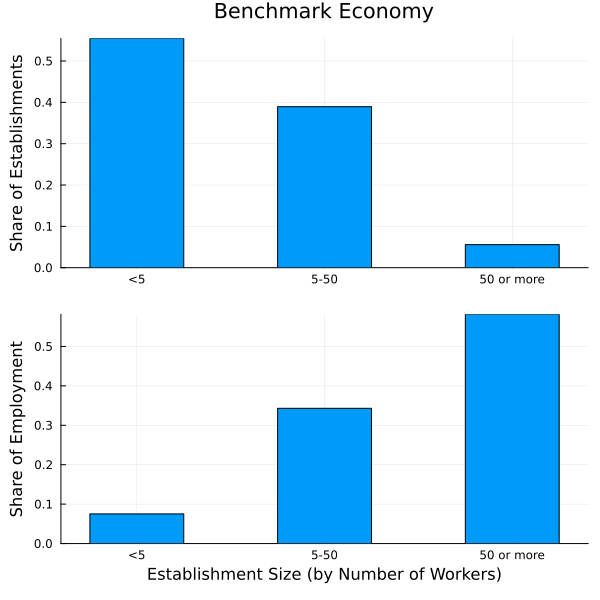

In [10]:
labels = ["<5", "5-50", "50 or more"]

  p1 = bar(labels, agg.cdf_plants,
           bar_width = 0.5,
           legend = false,
           title = "Benchmark Economy",
           ylabel = "Share of Establishments")

  p2 = bar(labels, agg.cdf_sN,
           bar_width = 0.5,
           legend = false,
           xlabel = "Establishment Size (by Number of Workers)",
           ylabel = "Share of Employment")

  plot(p1, p2, layout = (2, 1), size = (600, 600))

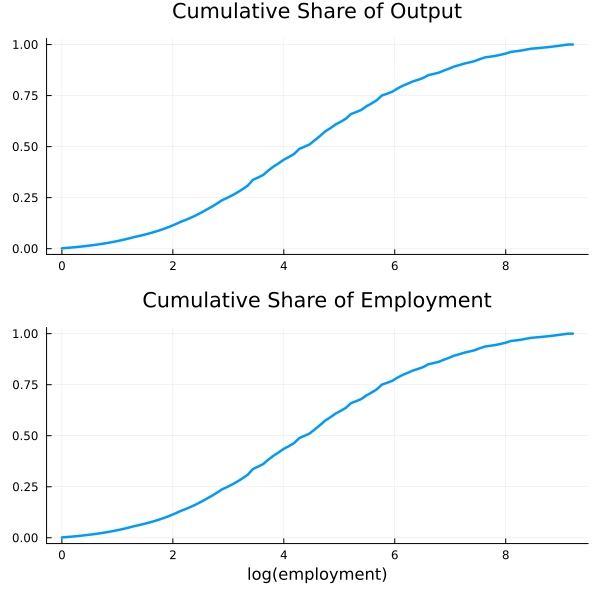

In [13]:
p3 = plot(log.(z), cumsum(agg.share_Y[:, 2]),
            linewidth = 2.5,
            legend = false,
            title = "Cumulative Share of Output")

  p4 = plot(log.(z), cumsum(agg.share_N[:, 2]),
            linewidth = 2.5,
            legend = false,
            title = "Cumulative Share of Employment",
            xlabel = "log(employment)")

  plot(p3, p4, layout = (2, 1), size = (600, 600))

In [33]:
ll = (agg.μ .* z)
ll = ll[:,2]
id_5 = (z .<5.0)
id_50 = (5.0.<=z .<50.0)
id_rest = (50.0.<=z )
avg_emm_5 = sum(ll[id_5])/sum(agg.μ[:,2][id_5])
avg_emm_50 = sum(ll[id_50])/sum(agg.μ[:,2][id_50])
avg_emm_rest = sum(ll[id_rest])/sum(agg.μ[:,2][id_rest])
println([avg_emm_5 avg_emm_50 avg_emm_rest ])

[2.384830430565429 15.486222415011333 183.0060923845219]


In [18]:
  function solve_distorted(par, F_dist, grid_τ; Kbe, norm_emp)
      # F_dist: 扭曲经济的进入分布 g（100×3）；grid_τ = [-τs, 0, τ]
      par_new = merge(par, (F = F_dist, grid_τ = grid_τ))
      sol = solve_wage(par_new)
      μ_hat = sol.χ .* F_dist ./ par_new.λ
      E     = 1.0 / sum(sol.n .* μ_hat)
      μ     = E .* μ_hat
      K     = sum(sol.k .* μ)
      K_τ = sum(sol.k .* μ, dims = 1)
      share_K_τ = K_τ ./ K
      y = par_new.grid_z .* sol.k .^α .* sol.n .^γ 
      Y = sum( y .* μ)
      Y_τ = sum(y .* μ, dims = 1)
      τ_agg = sum(repeat(par_new.grid_τ', par_new.N_z,1) .*y .*μ ,dims =1)[1]
      share_τ = τ_agg ./ Y
      share_Y_τ = Y_τ ./ Y
      A = Y/K^α
      n_norm = sol.n ./ norm_emp
      mass = sum(μ)
      emp_per_firm = 1.0 ./(mass .* norm_emp)
      share_K = (sol.k .* μ) ./ K 
      N = 1.0
      share_N = (sol.n .* μ) ./ N 
      share_Y = (y .* μ) ./Y

      return ( share_K_τ = share_K_τ[1], share_Y_τ = share_Y_τ[1], 
                sol = sol, μ = μ, E = E, K = K, 
                resid = K / Kbe - 1, par = par_new,
                share_τ = -share_τ, Y = Y, A = A)
  end
  τ = [0.1, 0.2, 0.3, 0.4]
  τs = fill(0.0,4)
  F_dist = hs[:] .* repeat([0.1 0.0 0.9],params.N_z,1)
  for i in 1:length(τ) 
    τs[i] = QuantEcon.brent(x -> solve_distorted(params, F_dist, [-x, 0.0, τ[i]]; Kbe = agg.K, norm_emp = agg.norm_emp).resid,
              0.00001, 0.99)
  end
  model_10pp = solve_distorted(params, F_dist, [-τs[1], 0.0, τ[1]]; Kbe = agg.K,norm_emp = agg.norm_emp)
  model_20pp = solve_distorted(params, F_dist, [-τs[2], 0.0, τ[2]]; Kbe = agg.K,norm_emp = agg.norm_emp)
  model_30pp = solve_distorted(params, F_dist, [-τs[3], 0.0, τ[3]]; Kbe = agg.K,norm_emp = agg.norm_emp)
  model_40pp = solve_distorted(params, F_dist, [-τs[4], 0.0, τ[4]]; Kbe = agg.K,norm_emp = agg.norm_emp)
  

(share_K_τ = 0.9701289254773205, share_Y_τ = 0.9326968965096513, sol = (V = [0.5517631092132245 0.05687523531408247 0.0018876937695064128; 0.6055593312061239 0.06242050054433264 0.002071741581662222; … ; 5027.459953135768 518.2259616349673 17.199962577255107; 5517.631092132284 568.7523531408297 18.876937695064264], π = [0.07503978285299853 0.007735032002715216 0.00025672635265287216; 0.08235606904403286 0.00848918807402924 0.0002817568551060622; … ; 683.7345536264645 70.47873078235557 2.339194910506695; 750.3978285299906 77.35032002715283 2.5672635265287402], n = [0.14955270415715258 0.01541575560012367 0.0005116502048367217; 0.16413390818862322 0.016918772740278396 0.0005615354681725715; … ; 1362.6685410435643 140.46262360211557 4.661966108060847; 1495.5270415715356 154.1575560012378 5.116502048367256], k = [1.1650011949780583 0.12008725483667451 0.003985705931597098; 1.2785873732863546 0.13179561393470032 0.004374307339546168; … ; 10615.056996940539 1094.1903409132822 36.316268016998

In [19]:
@printf("Varibles τ %.2f, %.2f, %.2f, %.2f\n", τ[1], τ[2], τ[3], τ[4])
@printf("Relative Y %2.2f, %2.2f, %2.2f, %2.2f\n", model_10pp.Y / agg.Y,model_20pp.Y / agg.Y,model_30pp.Y / agg.Y,model_40pp.Y / agg.Y)
@printf("Relative TFP %2.2f, %2.2f, %2.2f, %2.2f\n", model_10pp.A / agg.A,model_20pp.A / agg.A,model_30pp.A / agg.A,model_40pp.A / agg.A)
@printf("Ys/Y %2.2f, %2.2f, %2.2f, %2.2f\n", model_10pp.share_Y_τ,model_20pp.share_Y_τ,model_30pp.share_Y_τ,model_40pp.share_Y_τ)
@printf("S/Y %2.2f, %2.2f, %2.2f, %2.2f\n", model_10pp.share_τ,model_20pp.share_τ,model_30pp.share_τ,model_40pp.share_τ)
@printf("τs %2.2f, %2.2f, %2.2f, %2.2f\n", τs[1],τs[2],τs[3],τs[4])


Varibles τ 0.10, 0.20, 0.30, 0.40
Relative Y 0.92, 0.84, 0.78, 0.74
Relative TFP 0.92, 0.84, 0.78, 0.74
Ys/Y 0.46, 0.70, 0.85, 0.93
S/Y 0.14, 0.25, 0.33, 0.38
τs 0.29, 0.37, 0.39, 0.41
